In [ ]:
!pip install EMD-signal --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.0.0 requires multiprocess<0.70.17, but you have multiprocess 0.70.19 which is incompatible.


CELL 1:IMPORT LIBRARIES


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")      # Suppress non-critical runtime warnings

# ── Numerical & Data ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats              # For one-sample t-test (IMF classification)

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Signal Decomposition ──────────────────────────────────────────────────
from PyEMD import CEEMDAN            # CEEMDAN from the EMD-signal package

# ── Display helpers (Colab-friendly) ─────────────────────────────────────
from IPython.display import display

# Ensure reproducibility for all stochastic operations
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ All imports successful.")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")
print(f"   Matplotlib: {matplotlib.__version__}")


✅ All imports successful.
   NumPy  : 2.0.2
   Pandas : 2.2.2
   Matplotlib: 3.10.0


CELL 2 — PREPROCESSING FUNCTIONS  

MODULE: chronological_validation
# Purpose : Ensure temporal integrity of the raw minute-level dataset.
#   Steps :
#     1. Parse 'date' column to pandas Timestamp (timezone-aware → naive IST).
#     2. Sort ascending by timestamp (chronological order).
#     3. Drop exact duplicate timestamps (duplicated rows carry no information).

In [ ]:
def chronological_validation(df: pd.DataFrame) -> pd.DataFrame:
    print("\n[1/5] ── Chronological Validation ──────────────────────────────")

    # ✅ FIXED datetime parsing (strict format)
    df["date"] = pd.to_datetime(
        df["date"],
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )

    # Drop failed parses
    n_before = len(df)
    df = df.dropna(subset=["date"])
    n_dropped_nat = n_before - len(df)
    if n_dropped_nat:
        print(f"   ⚠  Dropped {n_dropped_nat} rows with unparseable timestamps.")

    # Sort chronologically
    df = df.sort_values("date").reset_index(drop=True)

    # Remove duplicates
    n_before = len(df)
    df = df.drop_duplicates(subset=["date"], keep="first").reset_index(drop=True)
    n_dups = n_before - len(df)
    if n_dups:
        print(f"   ⚠  Removed {n_dups} duplicate timestamp(s).")

    # Interval check
    df["_date_only"] = df["date"].dt.date
    irregular_days = []
    for day, grp in df.groupby("_date_only"):
        diffs = grp["date"].diff().dropna()
        expected = pd.Timedelta("1min")
        if not (diffs == expected).all():
            irregular_days.append(str(day))

    if irregular_days:
        print(f"   ⚠  Irregular minute intervals detected on {len(irregular_days)} day(s).")
        print(f"      First 5 affected: {irregular_days[:5]}")
    else:
        print("   ✅ Minute intervals are consistent across all trading days.")

    df = df.drop(columns=["_date_only"])
    print(f"   ✅ Records after validation: {len(df):,}")

    return df


 CELL 3 — PREPROCESSING: MARKET HOURS FILTERING

 PURPOSE:
#   Retain only minute bars that fall within the official NSE trading session.
#
# NSE Market Hours (IST):
#   Session open  : 09:15
#   Session close : 15:30
#   Pre-market    : before 09:15 → EXCLUDED
#   Post-market   : after  15:30 → EXCLUDED
#
# Rationale: Pre/post-market data represents different liquidity regimes
# and would contaminate the daily close derivation.

In [ ]:
def filter_market_hours(df: pd.DataFrame,
                        market_open: str  = "09:15",
                        market_close: str = "15:30") -> pd.DataFrame:
    """
    Filter out pre-market and post-market minute bars.

    Parameters
    ----------
    df           : Chronologically validated DataFrame with 'date' column.
    market_open  : NSE session start time string (default '09:15' IST).
    market_close : NSE session end   time string (default '15:30' IST).

    Returns
    -------
    pd.DataFrame with only within-session minute bars retained.
    """
    print("\n[CELL 3] ── Market Hours Filtering ──────────────────────────────")
    print(f"   Retaining records between {market_open} and {market_close} IST.")

    # Extract time component for vectorised comparison.
    # Using pandas Timestamp.time() avoids timezone-related edge cases.
    time_col = df["date"].dt.time
    t_open   = pd.Timestamp(f"2000-01-01 {market_open}").time()
    t_close  = pd.Timestamp(f"2000-01-01 {market_close}").time()

    mask     = (time_col >= t_open) & (time_col <= t_close)
    n_before = len(df)
    df       = df[mask].reset_index(drop=True)
    n_removed = n_before - len(df)

    print(f"   ⚠  Removed {n_removed:,} pre/post-market record(s).")
    print(f"   ✅ Records after market-hours filter: {len(df):,}")
    return df

CELL 4 — PREPROCESSING: MISSING VALUE HANDLING



In [ ]:
def handle_missing_values(df: pd.DataFrame,
                          ffill_limit: int           = 5,
                          corruption_threshold: float = 0.30) -> pd.DataFrame:
    """
    Detect, repair, or exclude missing minute-level data.

    Parameters
    ----------
    df                   : Market-hours-filtered DataFrame.
    ffill_limit          : Max consecutive NaN minutes to forward-fill.
    corruption_threshold : Missing-bar fraction above which a full day
                           is flagged as corrupted and excluded.

    Returns
    -------
    pd.DataFrame with missing values handled.
    """
    print("\n[CELL 4] ── Missing Value Handling ──────────────────────────────")

    # NSE complete session: 09:15 to 15:30 inclusive = 375 bars.
    EXPECTED_BARS_PER_DAY = 375

    df["_date_only"] = df["date"].dt.date
    corrupted_days   = []
    clean_frames     = []

    for day, grp in df.groupby("_date_only"):
        grp = grp.copy().set_index("date")

        # Build the full expected minute-frequency index for this session.
        full_idx = pd.date_range(
            start=f"{day} 09:15",
            end=f"{day} 15:30",
            freq="1min"
        )
        # Reindex to surface implicit gaps as explicit NaN rows.
        grp = grp.reindex(full_idx)
        grp.index.name = "date"

        # Compute fraction of missing close bars for this session.
        n_missing   = grp["close"].isna().sum()
        missing_pct = n_missing / EXPECTED_BARS_PER_DAY

        if missing_pct >= corruption_threshold:
            # Session is too corrupted to be reliable — exclude entirely.
            corrupted_days.append(str(day))
            continue

        # ── Repair Step A: Forward-fill for short gaps ─────────────────────
        # ffill_limit = 5 means at most 5 consecutive missing minutes are
        # filled with the last known price.
        grp = grp.ffill(limit=ffill_limit)

        # ── Repair Step B: Linear interpolation for moderate gaps ──────────
        # Applied column-wise to all numeric fields; limit_direction='both'
        # also handles leading/trailing NaNs (e.g., session opening gaps).
        numeric_cols = grp.select_dtypes(include=[np.number]).columns.tolist()
        grp[numeric_cols] = grp[numeric_cols].interpolate(
            method="linear", limit_direction="both"
        )

        grp = grp.reset_index()
        clean_frames.append(grp)

    if corrupted_days:
        print(f"   ⚠  Flagged & excluded {len(corrupted_days)} corrupted day(s): "
              f"{corrupted_days[:10]}{'...' if len(corrupted_days) > 10 else ''}")
    else:
        print("   ✅ No heavily corrupted trading days detected.")

    df = pd.concat(clean_frames, ignore_index=True) if clean_frames else df
    df = df.drop(columns=["_date_only"], errors="ignore")

    remaining_na = df["close"].isna().sum()
    print(f"   ✅ Remaining NaN in 'close' after repair: {remaining_na}")
    print(f"   ✅ Records after gap-fill: {len(df):,}")
    return df


CELL 5 — PREPROCESSING: DATA TYPE CLEANING      

In [ ]:
def clean_data_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Coerce OHLCV columns to correct numeric types and scrub formatting.

    Parameters
    ----------
    df : DataFrame potentially containing string-encoded numbers.

    Returns
    -------
    pd.DataFrame with clean numeric OHLCV types.
    """
    print("\n[CELL 5] ── Data Type Cleaning ───────────────────────────────────")

    price_cols  = ["open", "high", "low", "close"]
    volume_cols = ["volume"]
    all_numeric = price_cols + volume_cols

    for col in all_numeric:
        if col not in df.columns:
            continue
        if df[col].dtype == object:
            # Remove thousands separators and strip surrounding whitespace.
            df[col] = (
                df[col].astype(str)
                       .str.replace(",", "", regex=False)
                       .str.strip()
            )
        # Coerce to numeric; non-convertible values become NaN (safely).
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Cast price columns to float64 (double precision).
    for col in price_cols:
        if col in df.columns:
            df[col] = df[col].astype("float64")

    # Cast volume to int64; fill NaN with 0 before integer conversion.
    for col in volume_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype("int64")

    # Drop rows where ALL price columns are NaN (fully malformed rows).
    n_before = len(df)
    df = df.dropna(subset=price_cols, how="all").reset_index(drop=True)
    print(f"   ✅ Dropped {n_before - len(df)} fully-malformed price row(s).")
    print(f"   ✅ OHLCV dtypes: { {c: str(df[c].dtype) for c in all_numeric if c in df.columns} }")
    return df

 CELL 6 — PREPROCESSING: OUTLIER DETECTION  

In [ ]:
def detect_outliers(df: pd.DataFrame,
                    z_threshold: float = 4.0,
                    window: int        = 30) -> pd.DataFrame:
    """
    Detect and replace price-spike outliers using per-day rolling z-score.

    Parameters
    ----------
    df          : DataFrame with clean numeric OHLCV columns.
    z_threshold : Standard-deviation threshold for spike flagging (default 4.0).
    window      : Rolling window size in minutes for z-score calculation.

    Returns
    -------
    pd.DataFrame with outlier close values replaced by rolling median.
    """
    print("\n[CELL 6] ── Outlier Detection ────────────────────────────────────")

    df = df.copy()
    df["_date_only"] = df["date"].dt.date
    total_flagged    = 0

    for day, grp in df.groupby("_date_only"):
        idx   = grp.index
        close = df.loc[idx, "close"]

        # ── Rolling statistics (centred window for symmetric context) ──────
        roll_mean   = close.rolling(window=window, min_periods=5, center=True).mean()
        roll_std    = close.rolling(window=window, min_periods=5, center=True).std()
        roll_median = close.rolling(window=window, min_periods=5, center=True).median()

        # Avoid division-by-zero on near-constant price series segments.
        roll_std = roll_std.replace(0, np.nan)
        z_scores = (close - roll_mean) / roll_std

        spike_mask     = z_scores.abs() > z_threshold
        n_spikes       = spike_mask.sum()
        total_flagged += n_spikes

        if n_spikes:
            # Replace spike bars with the rolling median at that bar.
            df.loc[idx[spike_mask], "close"] = roll_median[spike_mask].values

    df = df.drop(columns=["_date_only"])
    print(f"   ✅ Total spike outliers replaced: {total_flagged}")

    # ── OHLC Consistency Check ─────────────────────────────────────────────
    # After outlier replacement, ensure: Low ≤ Close ≤ High.
    if all(c in df.columns for c in ["high", "low"]):
        ohlc_violations = (
            (df["close"] > df["high"]) | (df["close"] < df["low"])
        ).sum()
        if ohlc_violations:
            print(f"   ⚠  {ohlc_violations} OHLC consistency violation(s) — clamping close.")
            df["close"] = df["close"].clip(lower=df["low"], upper=df["high"])

    print("   ✅ Outlier detection complete.")
    return df

 CELL 7 — AGGREGATION: MINUTE → DAILY CLOSE  

In [ ]:
def aggregate_to_daily_close(df: pd.DataFrame,
                              output_path: str = "clean_daily_close.csv") -> pd.DataFrame:
    """
    Aggregate minute bars to daily close price.

    Parameters
    ----------
    df          : Fully preprocessed minute-level DataFrame.
    output_path : Path to write clean_daily_close.csv.

    Returns
    -------
    pd.DataFrame with columns [Date, Close] — one row per trading day.
    """
    print("\n[CELL 7] ── Minute-to-Daily Aggregation ─────────────────────────")

    df = df.copy()
    df["_date_only"] = df["date"].dt.date

    # Daily Close = last close per session (intraday bars are already sorted).
    daily = (
        df.groupby("_date_only")["close"]
        .last()
        .reset_index()
        .rename(columns={"_date_only": "Date", "close": "Close"})
    )

    # Convert from datetime.date → datetime64 for full pandas compatibility.
    daily["Date"] = pd.to_datetime(daily["Date"])

    # Enforce strict chronological order.
    daily = daily.sort_values("Date").reset_index(drop=True)

    # ── Final Validation ───────────────────────────────────────────────────
    print("\n   ── Final Validation ──────────────────────────────────────────")
    n_missing_close = daily["Close"].isna().sum()
    if n_missing_close:
        print(f"   ⚠  {n_missing_close} missing Close value(s) — dropping.")
        daily = daily.dropna(subset=["Close"]).reset_index(drop=True)
    else:
        print("   ✅ No missing values in daily Close.")

    print(f"   ✅ Total trading days: {len(daily)}")
    print(f"   ✅ Date range        : {daily['Date'].min().date()} → {daily['Date'].max().date()}")

    # Save two-column CSV — ONLY Date and Close.
    daily.to_csv(output_path, index=False)
    print(f"   ✅ Saved → '{output_path}'")
    print("\n   📋 Head of clean daily Close series:")
    print(daily.head(10).to_string(index=False))

    return daily

 CELL 8 — CEEMDAN DECOMPOSITION FUNCTION   

In [ ]:
def run_ceemdan(close_series: np.ndarray,
                random_seed: int = RANDOM_SEED) -> tuple:
    """
    Decompose the daily Close series via CEEMDAN.

    Parameters
    ----------
    close_series : 1-D numpy array of daily close prices (chronological).
    random_seed  : Integer seed for NumPy RNG (ensures reproducibility).

    Returns
    -------
    imfs     : np.ndarray shape (n_imfs, n_samples) — IMFs ordered
               from highest to lowest instantaneous frequency.
    residual : np.ndarray shape (n_samples,) — long-term trend residual.
    """
    print("\n[CELL 8] ── CEEMDAN Decomposition ───────────────────────────────")

    # Lock numpy RNG before CEEMDAN so ensemble noise is identical per run.
    np.random.seed(random_seed)

    # Instantiate CEEMDAN with default settings (no architectural modification).
    ceemdan = CEEMDAN()

    # Execute decomposition — returns ndarray of shape (n_imfs, n_samples).
    imfs = ceemdan(close_series)

    # Compute residual: the signal variance not captured by any IMF.
    # Formula: residual = original_signal − Σ IMFs
    residual = close_series - np.sum(imfs, axis=0)

    n_imfs = imfs.shape[0]
    print(f"   ✅ CEEMDAN complete.")
    print(f"   ✅ Total IMFs extracted      : {n_imfs}")
    print(f"   ✅ Residual range            : [{residual.min():.4f}, {residual.max():.4f}]")

    # Reconstruction sanity check — should be near machine epsilon (~1e-12).
    recon_error = np.max(np.abs(close_series - (np.sum(imfs, axis=0) + residual)))
    print(f"   ✅ Reconstruction error      : {recon_error:.6e}  (≈ machine epsilon ✓)")

    return imfs, residual

 CELL 9 — IMF CLASSIFICATION: ZERO-MEAN T-TEST   

In [ ]:
def classify_imfs(imfs: np.ndarray,
                  alpha: float = 0.05) -> dict:
    """
    Classify CEEMDAN IMFs as High-Frequency or Low-Frequency via t-test.

    Parameters
    ----------
    imfs  : np.ndarray of shape (n_imfs, n_samples).
    alpha : Significance level for the one-sample t-test (default 0.05).

    Returns
    -------
    dict with keys:
        'table'      → pd.DataFrame summary (IMF, Mean, t-stat, p-value, Class)
        'hf_indices' → list of 0-based indices for High-Frequency IMFs
        'lf_indices' → list of 0-based indices for Low-Frequency IMFs
        'hf_imfs'    → np.ndarray of High-Frequency IMF arrays
        'lf_imfs'    → np.ndarray of Low-Frequency  IMF arrays
    """
    print("\n[CELL 9] ── Zero-Mean T-Test IMF Classification ─────────────────")
    print(f"   H₀: mean(IMF) = 0  |  α = {alpha}")
    print(f"   p > {alpha}  →  High-Frequency  |  p ≤ {alpha}  →  Low-Frequency")
    print()

    records    = []
    hf_indices = []
    lf_indices = []

    for i, imf in enumerate(imfs):
        imf_number = i + 1

        # scipy.stats.ttest_1samp: one-sample t-test against popmean = 0.
        t_stat, p_value = stats.ttest_1samp(imf, popmean=0.0)
        imf_mean        = imf.mean()

        if p_value > alpha:
            classification = "High-Frequency"
            hf_indices.append(i)
            flag = "✅ HF"
        else:
            classification = "Low-Frequency"
            lf_indices.append(i)
            flag = "🔵 LF"

        records.append({
            "IMF Number"    : imf_number,
            "Mean"          : round(imf_mean, 6),
            "t-Statistic"   : round(t_stat,   4),
            "p-value"       : round(p_value,   6),
            "Classification": classification
        })
        print(f"   IMF-{imf_number:02d} | mean={imf_mean:+.6f} | "
              f"t={t_stat:+.4f} | p={p_value:.6f} | {flag}")

    table   = pd.DataFrame(records)
    hf_imfs = imfs[hf_indices] if hf_indices else np.empty((0, imfs.shape[1]))
    lf_imfs = imfs[lf_indices] if lf_indices else np.empty((0, imfs.shape[1]))

    print(f"\n   ✅ High-Frequency IMFs : {len(hf_indices)}  → IMF(s) {[i+1 for i in hf_indices]}")
    print(f"   ✅ Low-Frequency  IMFs : {len(lf_indices)}  → IMF(s) {[i+1 for i in lf_indices]}")
    print(f"   ✅ Residual            : 1")
    return {
        "table"     : table,
        "hf_indices": hf_indices,
        "lf_indices": lf_indices,
        "hf_imfs"   : hf_imfs,
        "lf_imfs"   : lf_imfs
    }

 CELL 10 — EXECUTION PIPELINE    

In [ ]:
DATA_PATH = "NIFTY 50_minute.csv"    # ← Actual dataset filename (note the space)

print("=" * 70)
print("  Phase 1 Pipeline: NIFTY 50 Intraday → Daily Close → CEEMDAN")
print("=" * 70)

# ── Step 0: Load Raw Data ─────────────────────────────────────────────────
print("\n[Step 0] Loading raw minute-level data …")
try:
    raw_df = pd.read_csv(DATA_PATH)
    print(f"   ✅ Loaded {len(raw_df):,} rows × {raw_df.shape[1]} columns.")
    print(f"   Columns detected: {list(raw_df.columns)}")
except FileNotFoundError:
    # ── Synthetic Fallback ─────────────────────────────────────────────────
    print("   ⚠  File not found → generating synthetic NIFTY 50 data for demo …")
    np.random.seed(RANDOM_SEED)

    trading_days = pd.bdate_range(start="2022-01-03", end="2023-12-29")
    records_list = []
    price = 17000.0

    for day in trading_days:
        minutes = pd.date_range(
            start=f"{day.date()} 09:15",
            end=f"{day.date()} 15:30",
            freq="1min"
        )
        n       = len(minutes)
        returns = np.random.normal(0, 0.0003, n)
        prices  = price * np.cumprod(1 + returns)
        price   = prices[-1]

        for i, ts in enumerate(minutes):
            o = prices[i] * (1 + np.random.uniform(-0.0002, 0.0002))
            h = prices[i] * (1 + abs(np.random.normal(0, 0.0003)))
            l = prices[i] * (1 - abs(np.random.normal(0, 0.0003)))
            c = prices[i]
            v = int(np.random.randint(10000, 200000))
            records_list.append({
                "date": ts, "open": o, "high": h,
                "low": l, "close": c, "volume": v
            })

    raw_df = pd.DataFrame(records_list)
    print(f"   ✅ Synthetic data generated: {len(raw_df):,} rows.")

# ── Steps 1–5: Sequential Preprocessing ──────────────────────────────────
df = chronological_validation(raw_df.copy())   # Cell 2
df = clean_data_types(df)                       # Cell 5 (called before filter)
df = filter_market_hours(df)                    # Cell 3
df = handle_missing_values(df)                  # Cell 4
df = detect_outliers(df)                        # Cell 6

# ── Step 6: Aggregate to Daily Close ─────────────────────────────────────
daily_df = aggregate_to_daily_close(df, output_path="clean_daily_close.csv")  # Cell 7

# ── Step 7: CEEMDAN Decomposition ────────────────────────────────────────
close_array    = daily_df["Close"].values.astype(np.float64)
imfs, residual = run_ceemdan(close_array, random_seed=RANDOM_SEED)            # Cell 8

# ── Step 8: IMF Classification ────────────────────────────────────────────
classification_results = classify_imfs(imfs, alpha=0.05)                      # Cell 9


  Phase 1 Pipeline: NIFTY 50 Intraday → Daily Close → CEEMDAN

[Step 0] Loading raw minute-level data …
   ✅ Loaded 975,321 rows × 6 columns.
   Columns detected: ['date', 'open', 'high', 'low', 'close', 'volume']

[1/5] ── Chronological Validation ──────────────────────────────
   ⚠  Removed 4 duplicate timestamp(s).
   ⚠  Irregular minute intervals detected on 29 day(s).
      First 5 affected: ['2015-03-13', '2015-07-20', '2015-08-24', '2015-09-02', '2015-09-07']
   ✅ Records after validation: 975,317

[CELL 5] ── Data Type Cleaning ───────────────────────────────────
   ✅ Dropped 0 fully-malformed price row(s).
   ✅ OHLCV dtypes: {'open': 'float64', 'high': 'float64', 'low': 'float64', 'close': 'float64', 'volume': 'int64'}

[CELL 3] ── Market Hours Filtering ──────────────────────────────
   Retaining records between 09:15 and 15:30 IST.
   ⚠  Removed 612 pre/post-market record(s).
   ✅ Records after market-hours filter: 974,705

[CELL 4] ── Missing Value Handling ────────────────

CELL 11 — PLOTS & SUMMARY OUTPUT  


── Generating Plots ─────────────────────────────────────────────────


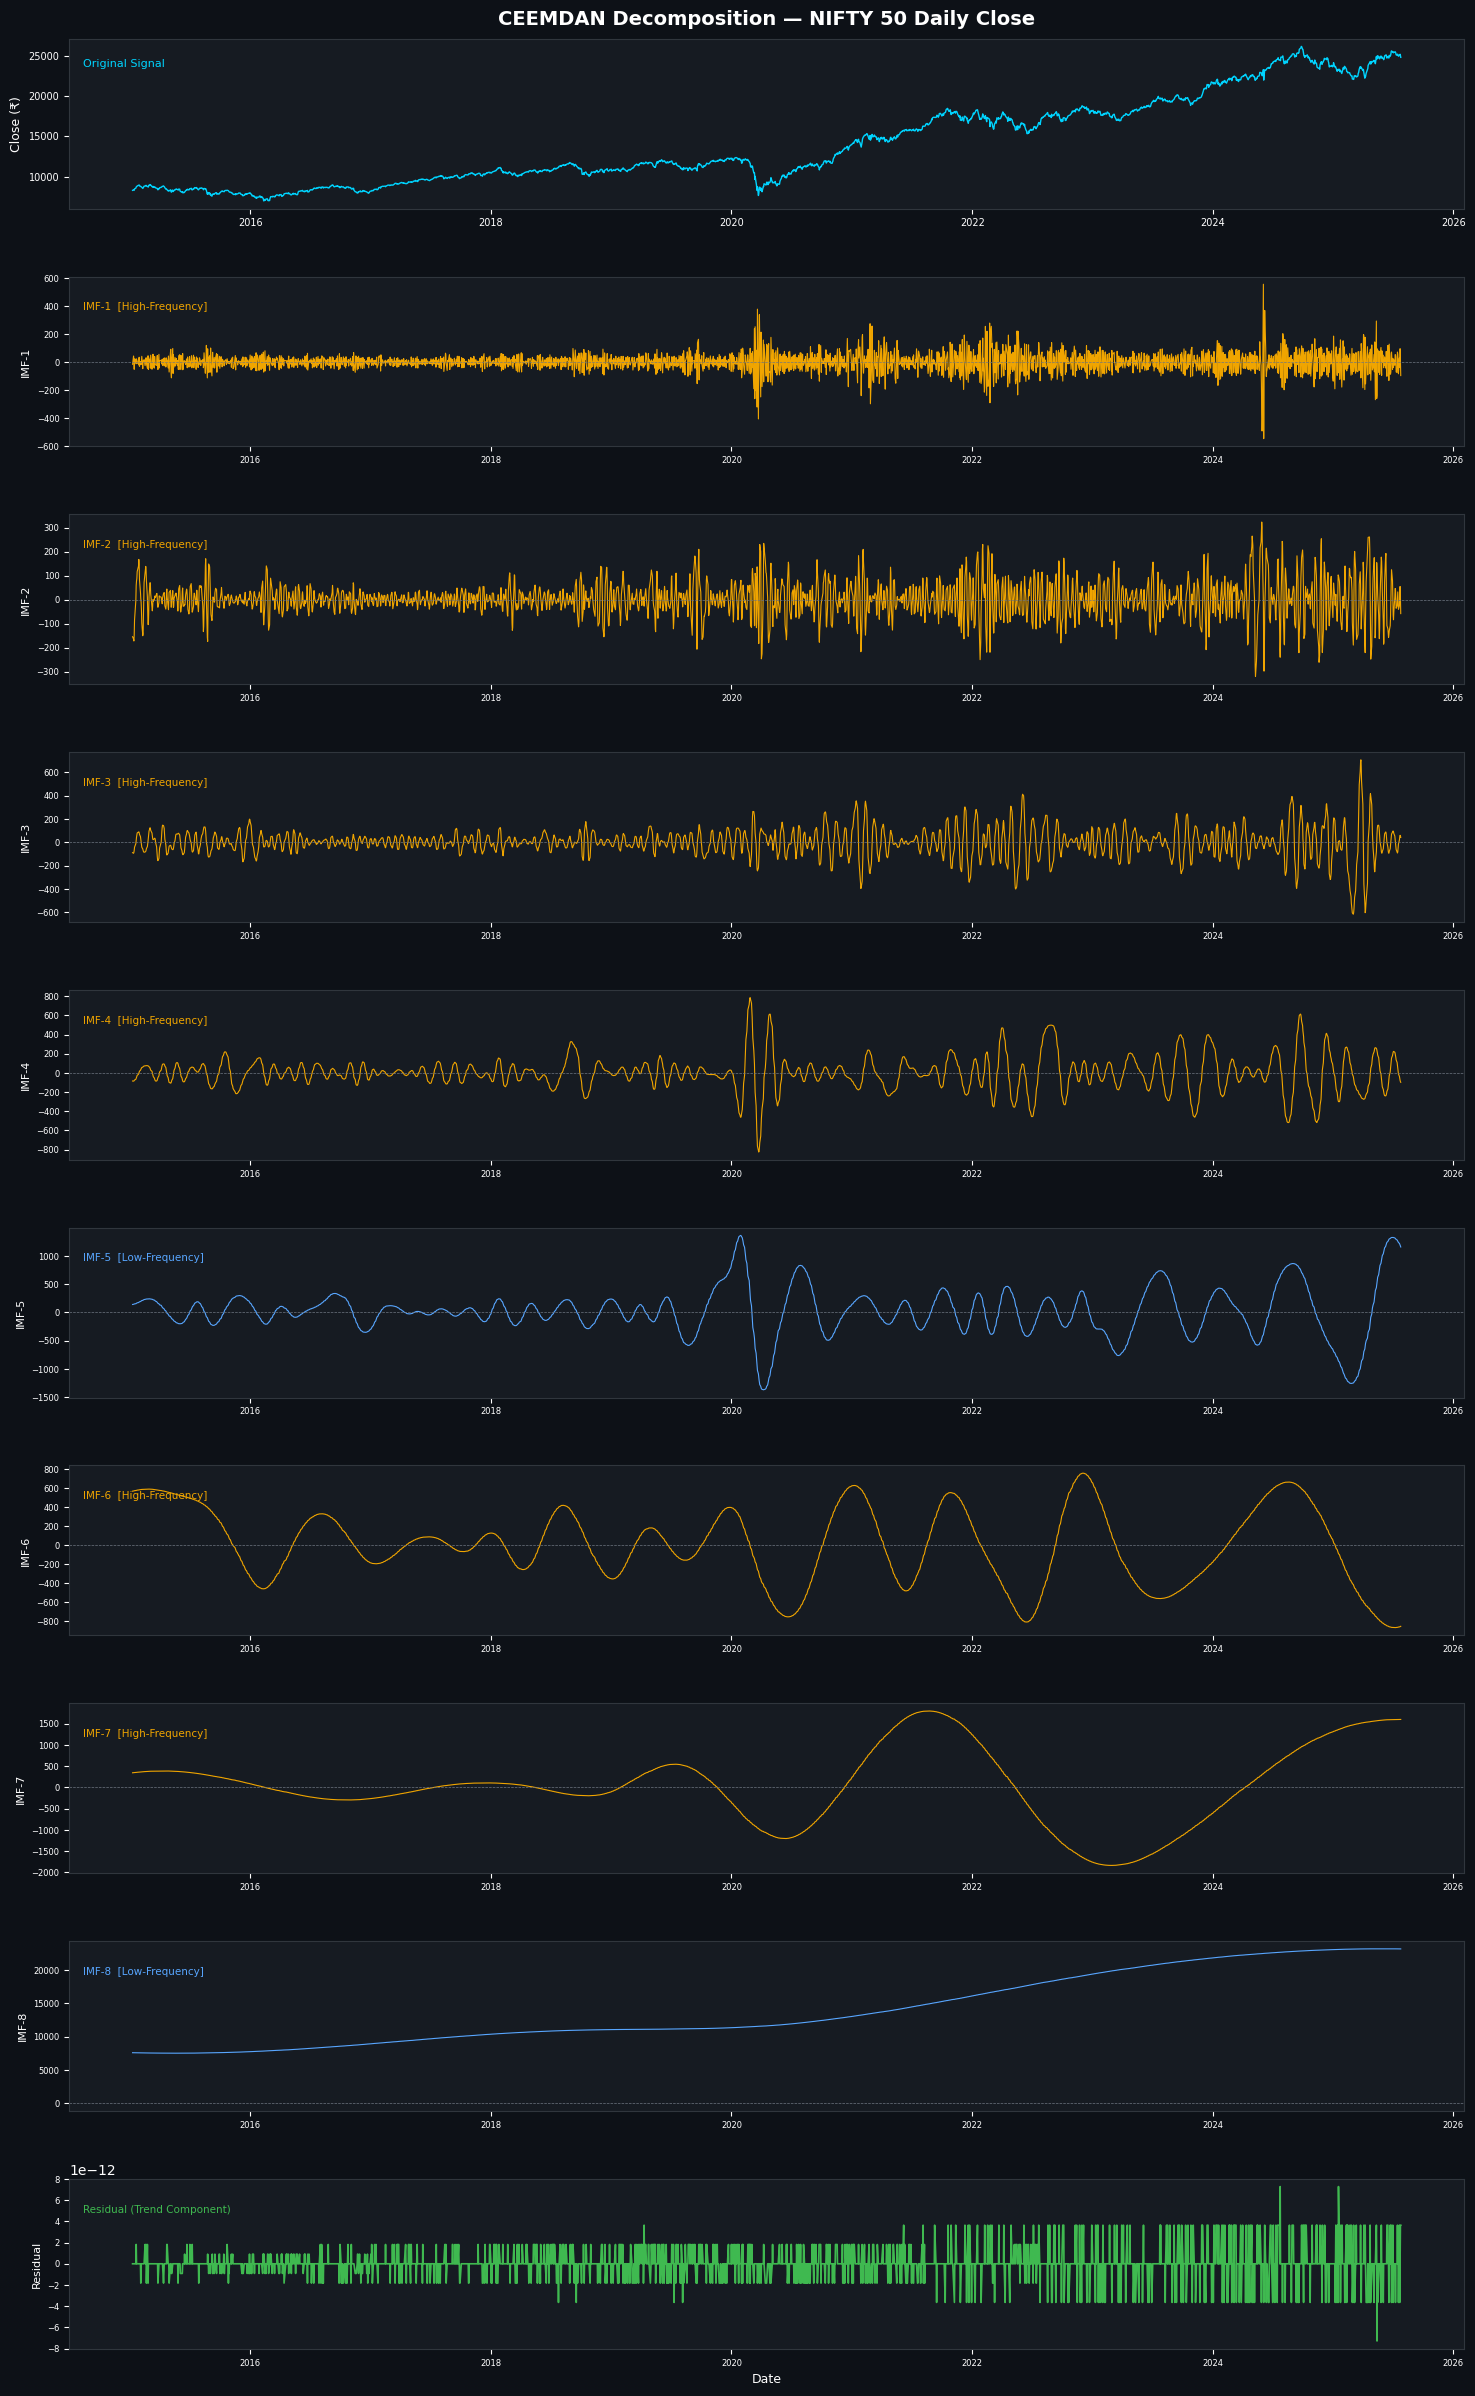

   ✅ Saved → 'ceemdan_decomposition.png'


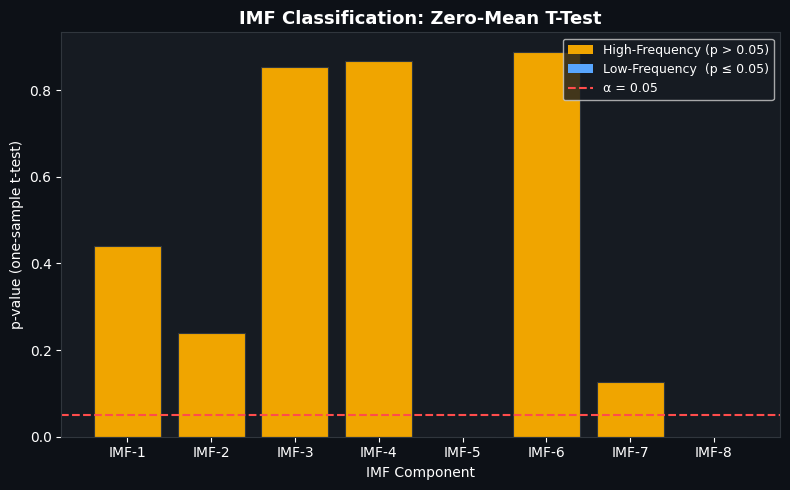

   ✅ Saved → 'imf_classification.png'


  PHASE 1 PIPELINE SUMMARY

📋 Cleaned Daily Close — First 10 Rows:
      Date   Close
2015-01-09 8280.25
2015-01-12 8326.55
2015-01-13 8303.80
2015-01-14 8287.75
2015-01-15 8461.15
2015-01-19 8550.30
2015-01-20 8691.25
2015-01-21 8728.05
2015-01-22 8762.20
2015-01-23 8823.55

📊 Total IMFs Extracted by CEEMDAN : 8

📋 IMF Classification Table (Zero-Mean T-Test):
----------------------------------------------------------------------
 IMF Number         Mean  t-Statistic  p-value Classification
          1     1.024822       0.7701 0.441283 High-Frequency
          2     1.676463       1.1749 0.240130 High-Frequency
          3     0.436437       0.1862 0.852314 High-Frequency
          4     0.575717       0.1660 0.868144 High-Frequency
          5    29.871668       3.5930 0.000333  Low-Frequency
          6    -1.084504      -0.1397 0.888929 High-Frequency
          7    26.477943       1.5290 0.126376 High-Frequency
          8 14016.589288     1

In [ ]:
def plot_ceemdan_decomposition(daily_df: pd.DataFrame,
                               imfs: np.ndarray,
                               residual: np.ndarray) -> None:
    """
    Publication-quality stacked plot of CEEMDAN components.
    Dark background follows financial chart conventions.
    """
    n_imfs   = imfs.shape[0]
    n_panels = 1 + n_imfs + 1          # original + IMFs + residual
    dates    = daily_df["Date"].values

    fig = plt.figure(figsize=(18, 3 * n_panels))
    fig.patch.set_facecolor("#0d1117")
    gs  = gridspec.GridSpec(n_panels, 1, figure=fig, hspace=0.4)

    # ── Panel 0: Original Daily Close ─────────────────────────────────────
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(dates, daily_df["Close"].values, color="#00d4ff", linewidth=1.0)
    ax0.set_ylabel("Close (₹)", color="white", fontsize=9)
    ax0.set_title("CEEMDAN Decomposition — NIFTY 50 Daily Close",
                  color="white", fontsize=14, fontweight="bold", pad=10)
    ax0.set_facecolor("#161b22")
    ax0.tick_params(colors="white", labelsize=7)
    ax0.spines[:].set_color("#30363d")
    ax0.text(0.01, 0.88, "Original Signal",
             transform=ax0.transAxes, color="#00d4ff", fontsize=8, va="top")

    # ── Panels 1…n_imfs: Individual IMFs ──────────────────────────────────
    hf_set   = set(classification_results["hf_indices"])
    color_hf = "#f0a500"    # amber  → High-Frequency
    color_lf = "#58a6ff"    # blue   → Low-Frequency

    for i in range(n_imfs):
        ax        = fig.add_subplot(gs[i + 1])
        imf_color = color_hf if i in hf_set else color_lf
        imf_label = "High-Frequency" if i in hf_set else "Low-Frequency"
        ax.plot(dates, imfs[i], color=imf_color, linewidth=0.8)
        ax.axhline(0, color="#6e7681", linewidth=0.5, linestyle="--")
        ax.set_ylabel(f"IMF-{i+1}", color="white", fontsize=8)
        ax.set_facecolor("#161b22")
        ax.tick_params(colors="white", labelsize=6)
        ax.spines[:].set_color("#30363d")
        ax.text(0.01, 0.85, f"IMF-{i+1}  [{imf_label}]",
                transform=ax.transAxes, color=imf_color, fontsize=7.5, va="top")

    # ── Last Panel: Residual ───────────────────────────────────────────────
    ax_r = fig.add_subplot(gs[-1])
    ax_r.plot(dates, residual, color="#3fb950", linewidth=1.2)
    ax_r.set_ylabel("Residual", color="white", fontsize=8)
    ax_r.set_xlabel("Date",     color="white", fontsize=9)
    ax_r.set_facecolor("#161b22")
    ax_r.tick_params(colors="white", labelsize=6)
    ax_r.spines[:].set_color("#30363d")
    ax_r.text(0.01, 0.85, "Residual (Trend Component)",
              transform=ax_r.transAxes, color="#3fb950", fontsize=7.5, va="top")

    plt.savefig("ceemdan_decomposition.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("   ✅ Saved → 'ceemdan_decomposition.png'")


# ---------------------------------------------------------------------------
# PLOT 2: IMF Classification p-Value Bar Chart
#   • Bar height = p-value for each IMF
#   • Dashed red line at α = 0.05 decision boundary
#   • Colour-coded by classification decision
# ---------------------------------------------------------------------------

def plot_imf_classification(classification_results: dict) -> None:
    """
    Bar chart: p-values per IMF with α = 0.05 threshold decision line.
    """
    from matplotlib.patches import Patch

    table = classification_results["table"]
    colors = [
        "#f0a500" if c == "High-Frequency" else "#58a6ff"
        for c in table["Classification"]
    ]

    fig, ax = plt.subplots(figsize=(max(8, len(table) * 1.0), 5))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#161b22")

    ax.bar(
        [f"IMF-{r}" for r in table["IMF Number"]],
        table["p-value"],
        color=colors, edgecolor="#30363d", linewidth=0.8
    )
    ax.axhline(y=0.05, color="#ff4c4c", linewidth=1.5,
               linestyle="--", label="α = 0.05")

    ax.set_xlabel("IMF Component",              color="white", fontsize=10)
    ax.set_ylabel("p-value (one-sample t-test)", color="white", fontsize=10)
    ax.set_title("IMF Classification: Zero-Mean T-Test",
                 color="white", fontsize=13, fontweight="bold")
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#30363d")

    legend_elements = [
        Patch(facecolor="#f0a500", label="High-Frequency (p > 0.05)"),
        Patch(facecolor="#58a6ff", label="Low-Frequency  (p ≤ 0.05)"),
        plt.Line2D([0], [0], color="#ff4c4c", linestyle="--", label="α = 0.05")
    ]
    ax.legend(handles=legend_elements, facecolor="#161b22",
              labelcolor="white", fontsize=9)

    plt.tight_layout()
    plt.savefig("imf_classification.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("   ✅ Saved → 'imf_classification.png'")


# ── Execute Plots ─────────────────────────────────────────────────────────
print("\n── Generating Plots ─────────────────────────────────────────────────")
plot_ceemdan_decomposition(daily_df, imfs, residual)
plot_imf_classification(classification_results)


# ── Final Summary ─────────────────────────────────────────────────────────
print("\n")
print("=" * 70)
print("  PHASE 1 PIPELINE SUMMARY")
print("=" * 70)

print("\n📋 Cleaned Daily Close — First 10 Rows:")
print(daily_df.head(10).to_string(index=False))

print(f"\n📊 Total IMFs Extracted by CEEMDAN : {imfs.shape[0]}")

print("\n📋 IMF Classification Table (Zero-Mean T-Test):")
print("-" * 70)
print(classification_results["table"].to_string(index=False))
print("-" * 70)

hf_count = len(classification_results["hf_indices"])
lf_count = len(classification_results["lf_indices"])
print(f"\n   High-Frequency IMFs : {hf_count}")
print(f"   Low-Frequency  IMFs : {lf_count}")
print(f"   Residual             : 1")

print("\n")
print("=" * 70)
print("  ✅ PHASE 1 COMPLETE")
print("  ✅ clean_daily_close.csv  — saved & validated.")
print("  ✅ CEEMDAN decomposition  — reproducible (seed=42).")
print("  ✅ IMF classification     — completed via t-test.")
print("  ✅ Dataset ready for Phase 2 modelling.")
print()
print("  ⛔  No deep learning models implemented in this phase.")
print("      Next: LSTM Baseline → Transformer / Informer.")
print("=" * 70)


In [ ]:
# ── Step 9: Save CEEMDAN Components for Phase 2 ─────────────────────────

import os
import pandas as pd

print("\n[Step 9] Saving CEEMDAN components …")

# Convert IMFs (shape: n_imfs × n_samples) → (n_samples × n_imfs)
imf_df = pd.DataFrame(
    imfs.T,
    columns=[f"IMF{i+1}" for i in range(imfs.shape[0])]
)

# Add Residual
imf_df["Residual"] = residual

# Add Close (from daily_df)
imf_df["Close"] = daily_df["Close"].values

# Add Date
imf_df.insert(0, "Date", daily_df["Date"].values)

# Create folder if not exists
os.makedirs("data", exist_ok=True)

# Save file
file_path = "data/ceemdan_components.csv"
imf_df.to_csv(file_path, index=False)

print("   ✅ ceemdan_components.csv saved successfully!")
print("   📁 Location:", file_path)
print("   📊 Shape:", imf_df.shape)
print(imf_df.head())


[Step 9] Saving CEEMDAN components …
   ✅ ceemdan_components.csv saved successfully!
   📁 Location: data/ceemdan_components.csv
   📊 Shape: (2599, 11)
        Date       IMF1        IMF2       IMF3       IMF4        IMF5  \
0 2015-01-09 -15.100180 -154.518802 -89.546888 -83.910007  141.715351   
1 2015-01-12  43.856125 -164.214023 -94.877037 -84.917763  143.784123   
2 2015-01-13  16.679773 -172.297581 -87.600744 -83.375312  146.218221   
3 2015-01-14 -51.227531 -146.982995 -68.915733 -79.501645  148.996511   
4 2015-01-15  23.250255  -84.556741 -42.560519 -73.607587  152.089107   

         IMF6        IMF7         IMF8  Residual    Close  
0  565.820437  343.343405  7572.446685       0.0  8280.25  
1  567.219018  344.742692  7570.956864       0.0  8326.55  
2  568.573828  346.120716  7569.481099       0.0  8303.80  
3  569.884615  347.477327  7568.019449       0.0  8287.75  
4  571.151132  348.812381  7566.571971       0.0  8461.15  
